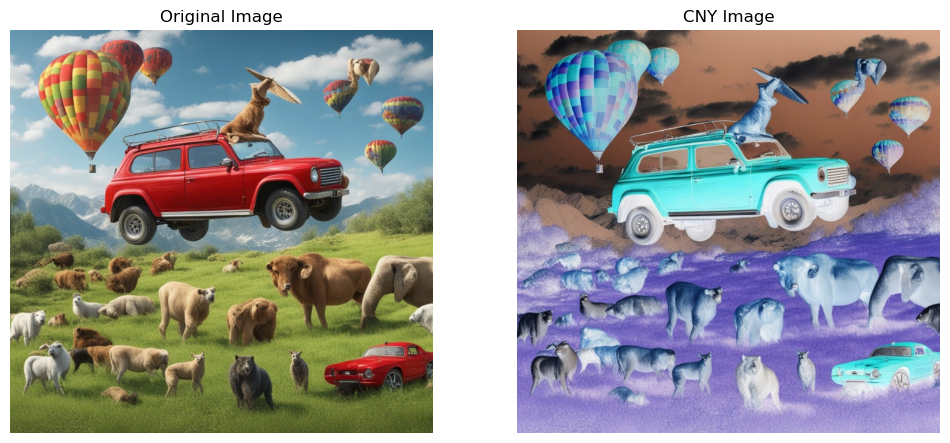

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path ="C:/Users/student/Documents/Computer Vision 2023510051/Scene.jpg"
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

cny_array = np.zeros_like(rgb_array)
cny_array[..., 0] = 255 - rgb_array[..., 0]
cny_array[..., 1] = 255 - rgb_array[..., 1]
cny_array[..., 2] = 255 - rgb_array[..., 2]

cny_image = Image.fromarray(cny_array)

# Display the original and CNY images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(cny_image)
axes[1].set_title("CNY Image")
axes[1].axis('off')

plt.show()


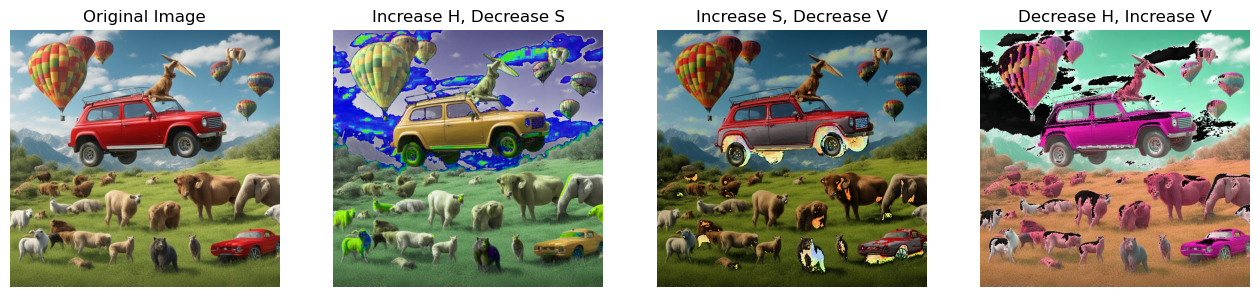

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path ="C:/Users/student/Documents/Computer Vision 2023510051/Scene.jpg"
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

# Convert RGB to HSV
hsv_image = image.convert("HSV")
hsv_array = np.array(hsv_image)

# Case 1: Increase Hue (H), Decrease Saturation (S)
hsv_array_case1 = hsv_array.copy()
hsv_array_case1[..., 0] = np.clip(hsv_array_case1[..., 0] + 30, 0, 255)  # Increase Hue
hsv_array_case1[..., 1] = np.clip(hsv_array_case1[..., 1] - 50, 0, 255)  # Decrease Saturation
image_case1 = Image.fromarray(hsv_array_case1, mode="HSV")

# Case 2: Increase Saturation (S), Decrease Value (V)
hsv_array_case2 = hsv_array.copy()
hsv_array_case2[..., 1] = np.clip(hsv_array_case2[..., 1] + 50, 0, 255)  # Increase Saturation
hsv_array_case2[..., 2] = np.clip(hsv_array_case2[..., 2] - 50, 0, 255)  # Decrease Value
image_case2 = Image.fromarray(hsv_array_case2, mode="HSV")

# Case 3: Decrease Hue (H), Increase Value (V)
hsv_array_case3 = hsv_array.copy()
hsv_array_case3[..., 0] = np.clip(hsv_array_case3[..., 0] - 30, 0, 255)  # Decrease Hue
hsv_array_case3[..., 2] = np.clip(hsv_array_case3[..., 2] + 50, 0, 255)  # Increase Value
image_case3 = Image.fromarray(hsv_array_case3, mode="HSV")

# Display the original and modified HSV images side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(image_case1)
axes[1].set_title("Increase H, Decrease S")
axes[1].axis('off')

axes[2].imshow(image_case2)
axes[2].set_title("Increase S, Decrease V")
axes[2].axis('off')

axes[3].imshow(image_case3)
axes[3].set_title("Decrease H, Increase V")
axes[3].axis('off')

plt.show()



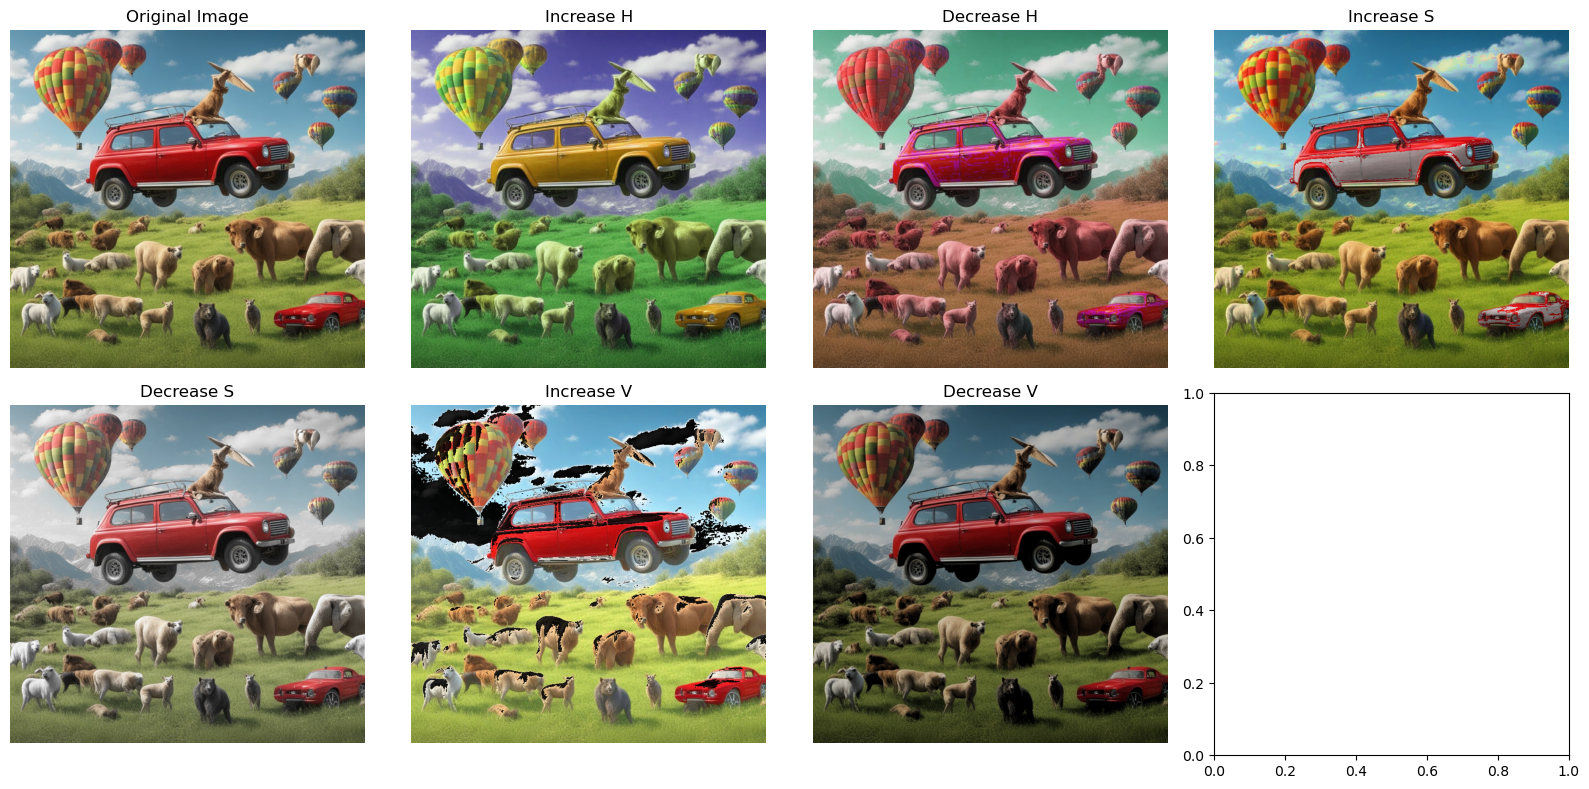

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Scene.jpg"
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

# Convert RGB to HSV
hsv_image = image.convert("HSV")
hsv_array = np.array(hsv_image)

# Define the adjustment values
adjustments = {
    "Increase H": (30, 0, 0),   # Increase Hue
    "Decrease H": (-30, 0, 0),  # Decrease Hue
    "Increase S": (0, 50, 0),   # Increase Saturation
    "Decrease S": (0, -50, 0),  # Decrease Saturation
    "Increase V": (0, 0, 50),   # Increase Value
    "Decrease V": (0, 0, -50),  # Decrease Value
}

# Function to apply the adjustments
def adjust_hsv(hsv_array, h, s, v):
    adjusted_array = hsv_array.copy()
    adjusted_array[..., 0] = np.clip(adjusted_array[..., 0] + h, 0, 255)  # Hue adjustment
    adjusted_array[..., 1] = np.clip(adjusted_array[..., 1] + s, 0, 255)  # Saturation adjustment
    adjusted_array[..., 2] = np.clip(adjusted_array[..., 2] + v, 0, 255)  # Value adjustment
    return adjusted_array

# Generate images for all possible combinations
adjusted_images = {}
for adjustment_name, (h, s, v) in adjustments.items():
    adjusted_array = adjust_hsv(hsv_array, h, s, v)
    adjusted_image = Image.fromarray(adjusted_array, mode="HSV")
    adjusted_images[adjustment_name] = adjusted_image

# Display the original and all adjusted images side by side
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Show the original image
axes[0, 0].imshow(image)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

# Show all the adjusted images
for idx, (adjustment_name, img) in enumerate(adjusted_images.items()):
    ax = axes[(idx+1)//4, (idx+1)%4]
    ax.imshow(img)
    ax.set_title(adjustment_name)
    ax.axis('off')

plt.tight_layout()
plt.show()


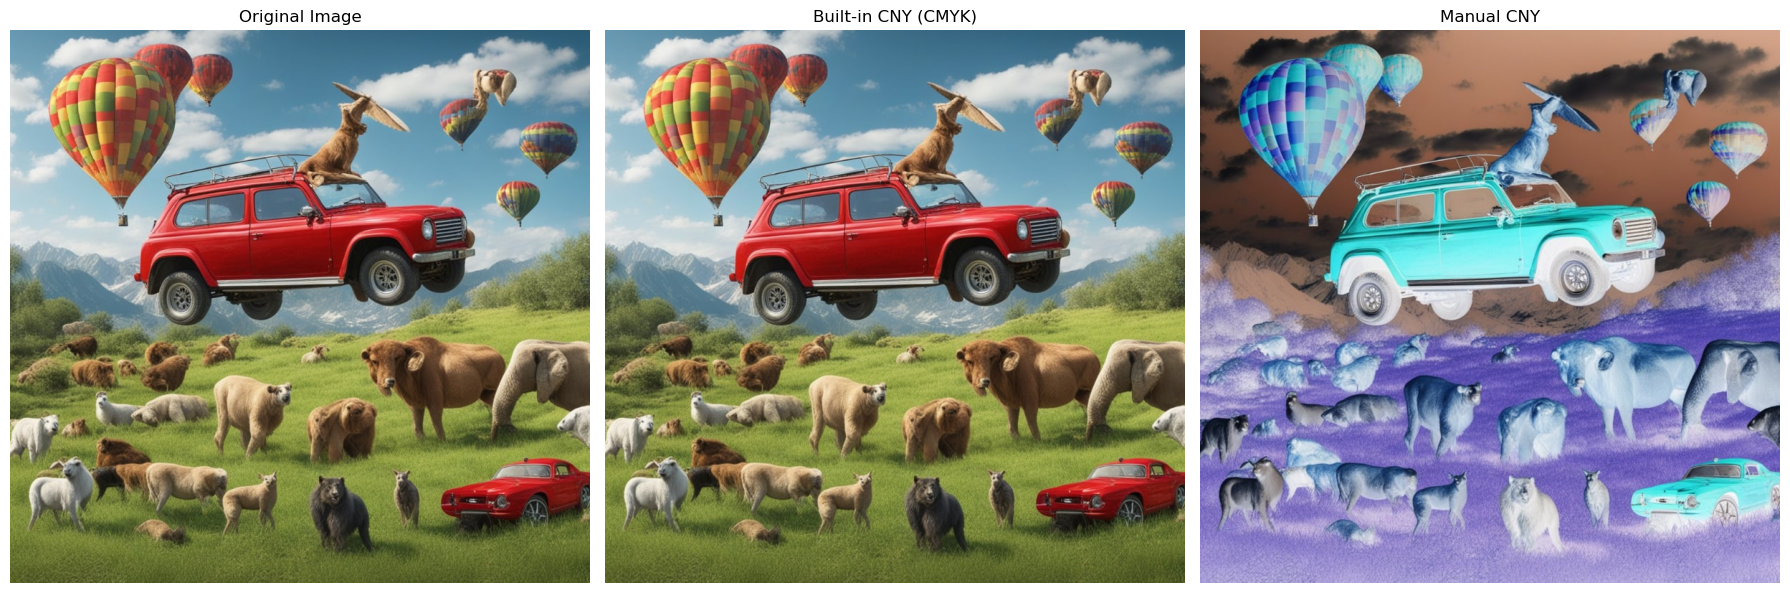

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Scene.jpg"
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

# Built-in conversion using PIL (ImageOps)
cny_image_built_in = image.convert("CMYK")  # Convert to CMYK as an approximation of CNY

# Manual RGB to CNY conversion (Inversion of RGB channels)
cny_array_manual = np.zeros_like(rgb_array)
cny_array_manual[..., 0] = 255 - rgb_array[..., 0]  # Cyan = 255 - Red
cny_array_manual[..., 1] = 255 - rgb_array[..., 1]  # Magenta = 255 - Green
cny_array_manual[..., 2] = 255 - rgb_array[..., 2]  # Yellow = 255 - Blue

cny_image_manual = Image.fromarray(cny_array_manual)

# Display the original and converted images side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Built-in CNY (CMYK) image
axes[1].imshow(cny_image_built_in)
axes[1].set_title("Built-in CNY (CMYK)")
axes[1].axis('off')

# Manual CNY image
axes[2].imshow(cny_image_manual)
axes[2].set_title("Manual CNY")
axes[2].axis('off')

plt.tight_layout()
plt.show()


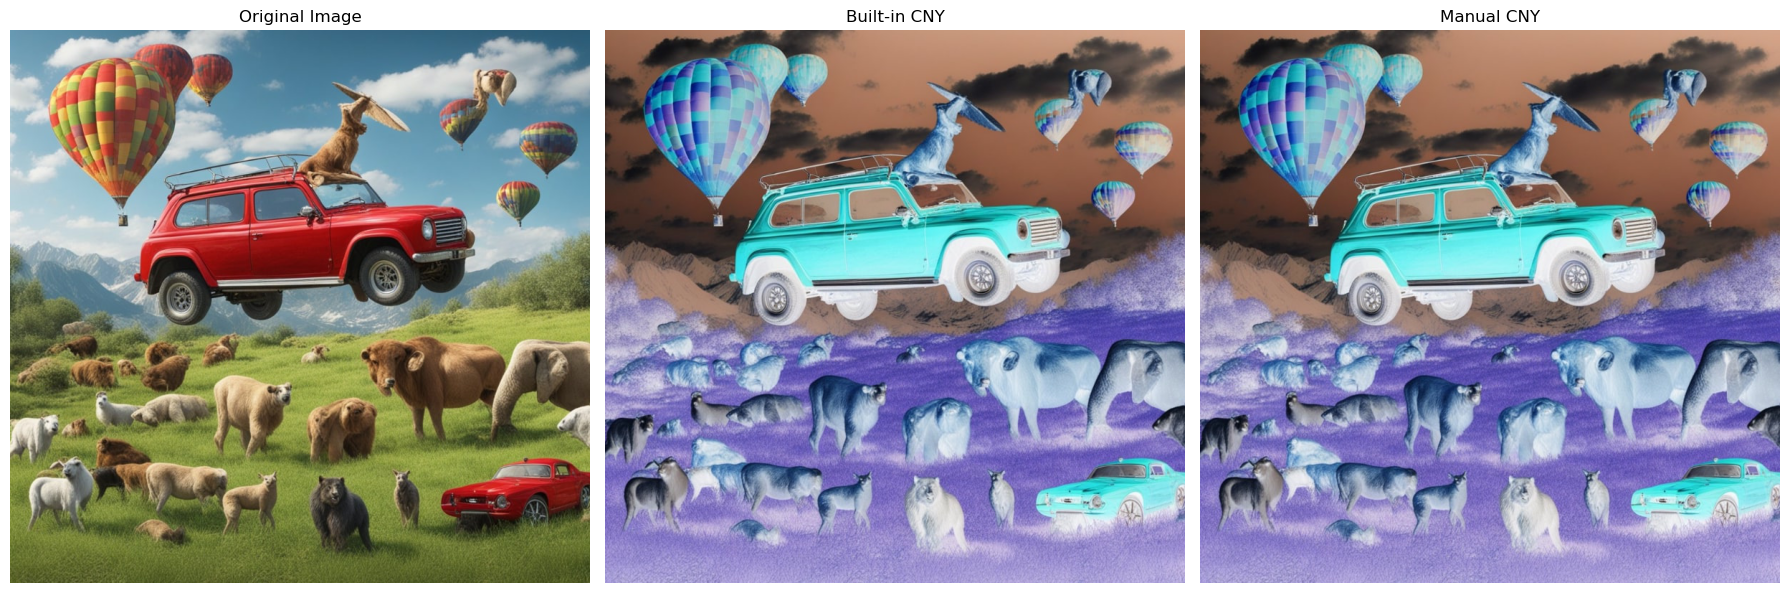

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Scene.jpg"
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

# Manual RGB to CNY Conversion (Inversion of RGB channels)
cny_array_manual = np.zeros_like(rgb_array)
cny_array_manual[..., 0] = 255 - rgb_array[..., 0]  # Cyan = 255 - Red
cny_array_manual[..., 1] = 255 - rgb_array[..., 1]  # Magenta = 255 - Green
cny_array_manual[..., 2] = 255 - rgb_array[..., 2]  # Yellow = 255 - Blue

cny_image_manual = Image.fromarray(cny_array_manual)

# Built-in RGB to CNY Conversion (Using numpy to manually invert RGB)
cny_array_built_in = np.zeros_like(rgb_array)
cny_array_built_in[..., 0] = 255 - rgb_array[..., 0]  # Cyan = 255 - Red
cny_array_built_in[..., 1] = 255 - rgb_array[..., 1]  # Magenta = 255 - Green
cny_array_built_in[..., 2] = 255 - rgb_array[..., 2]  # Yellow = 255 - Blue

cny_image_built_in = Image.fromarray(cny_array_built_in)

# Display the original and both CNY images side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Built-in CNY image (manual matrix operation)
axes[1].imshow(cny_image_built_in)
axes[1].set_title("Built-in CNY")
axes[1].axis('off')

# Manual CNY image
axes[2].imshow(cny_image_manual)
axes[2].set_title("Manual CNY")
axes[2].axis('off')

plt.tight_layout()
plt.show()


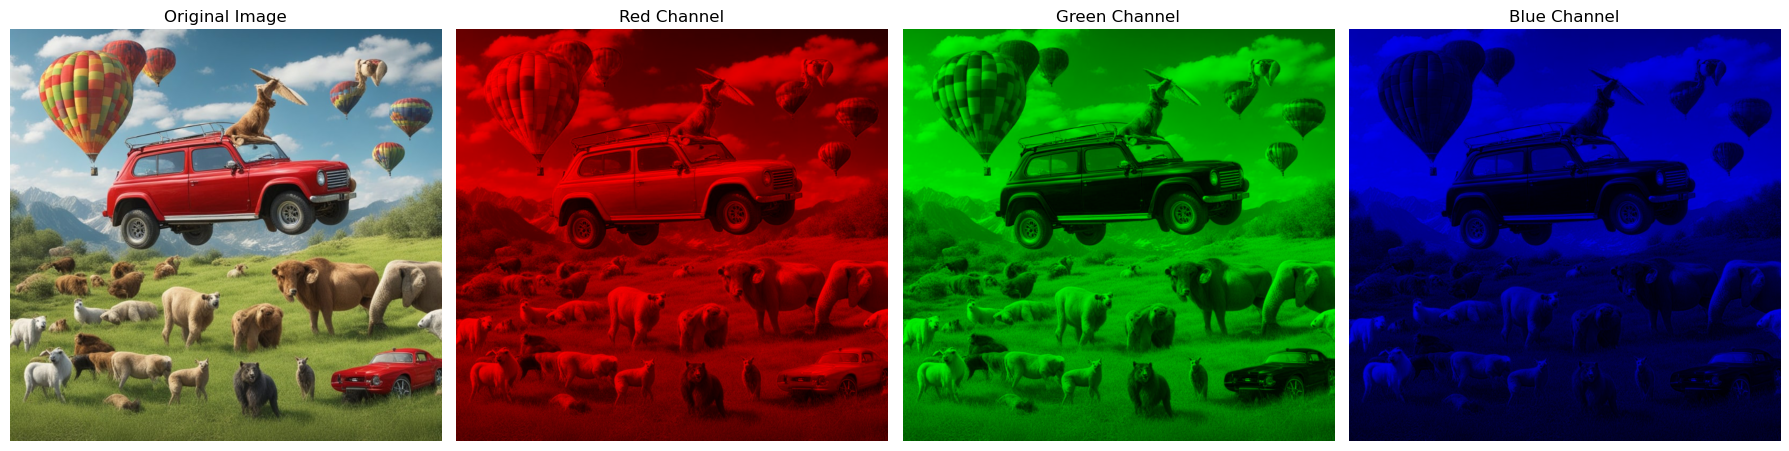

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path =  "C:/Users/student/Documents/Computer Vision 2023510051/Scene.jpg"
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

# Separate the RGB channels
r_channel = rgb_array.copy()
r_channel[..., 1:] = 0  # Set G and B channels to 0

g_channel = rgb_array.copy()
g_channel[..., [0, 2]] = 0  # Set R and B channels to 0

b_channel = rgb_array.copy()
b_channel[..., :2] = 0  # Set R and G channels to 0

# Convert the separated channels back to images
r_image = Image.fromarray(r_channel)
g_image = Image.fromarray(g_channel)
b_image = Image.fromarray(b_channel)

# Display the original and separated channels side by side
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Red channel image
axes[1].imshow(r_image)
axes[1].set_title("Red Channel")
axes[1].axis('off')

# Green channel image
axes[2].imshow(g_image)
axes[2].set_title("Green Channel")
axes[2].axis('off')

# Blue channel image
axes[3].imshow(b_image)
axes[3].set_title("Blue Channel")
axes[3].axis('off')

plt.tight_layout()
plt.show()


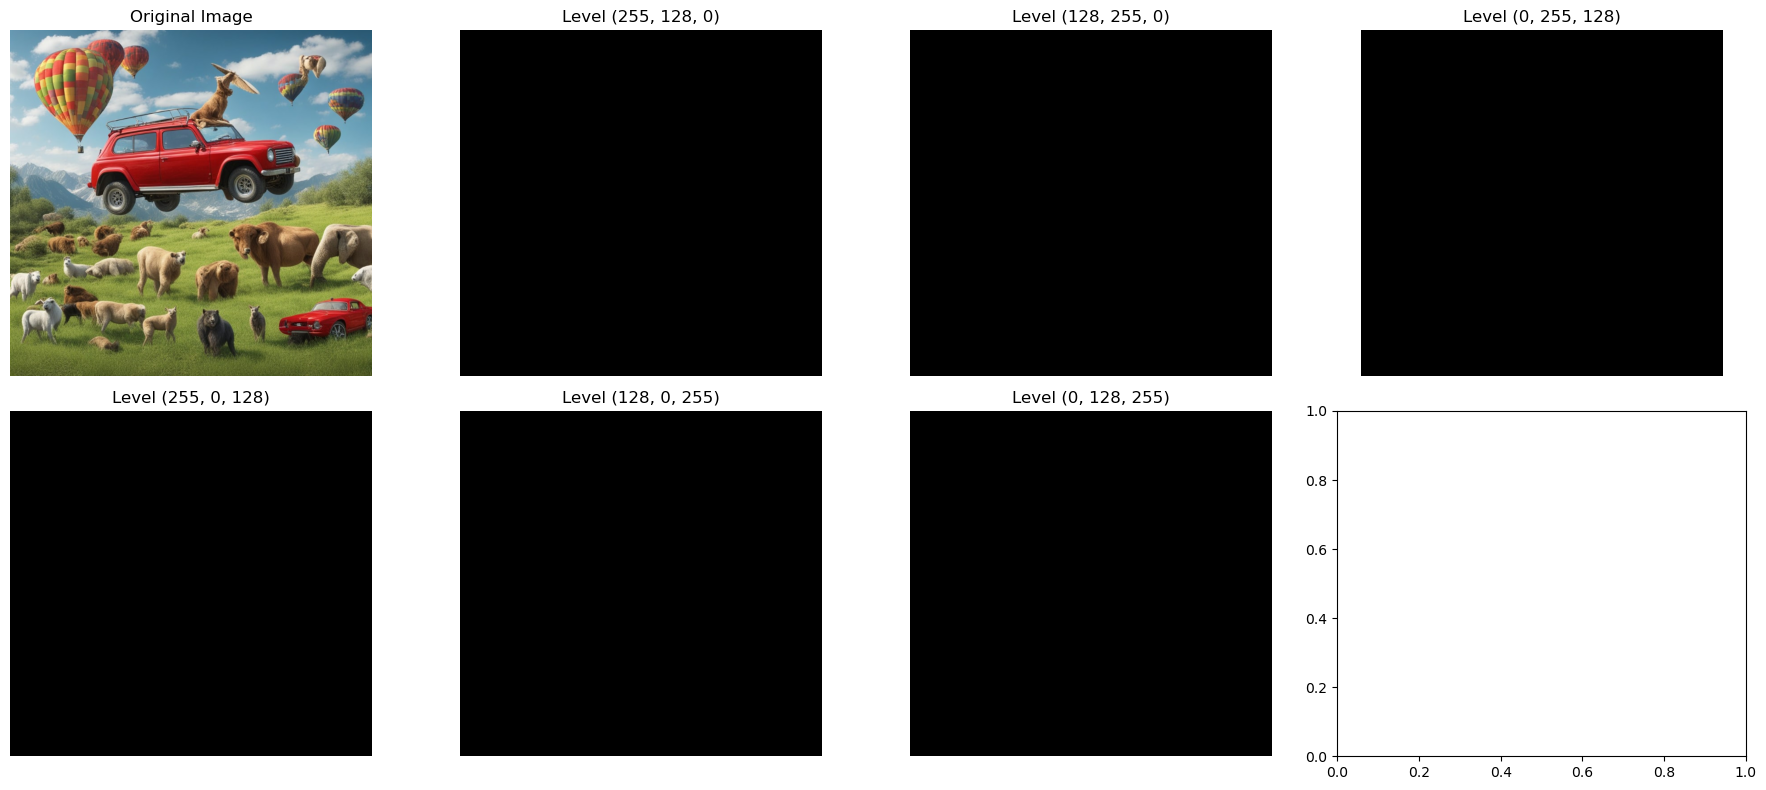

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path ="C:/Users/student/Documents/Computer Vision 2023510051/Scene.jpg"
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

# Apply custom level changes to the color channels
# Example level changes like (255, 128, 0) or other combinations
def apply_level_changes(rgb_array, r_level, g_level, b_level):
    modified_array = rgb_array.copy()
    modified_array[..., 0] = np.clip(modified_array[..., 0] * r_level / 255, 0, 255)  # Adjust Red channel
    modified_array[..., 1] = np.clip(modified_array[..., 1] * g_level / 255, 0, 255)  # Adjust Green channel
    modified_array[..., 2] = np.clip(modified_array[..., 2] * b_level / 255, 0, 255)  # Adjust Blue channel
    return modified_array

# Create different combinations of levels
levels = [
    (255, 128, 0),  # Red high, Green medium, Blue low
    (128, 255, 0),  # Red medium, Green high, Blue low
    (0, 255, 128),  # Red low, Green high, Blue medium
    (255, 0, 128),  # Red high, Green low, Blue medium
    (128, 0, 255),  # Red medium, Green low, Blue high
    (0, 128, 255),  # Red low, Green medium, Blue high
]

# Create images for each level combination
level_images = []
for r_level, g_level, b_level in levels:
    modified_rgb_array = apply_level_changes(rgb_array, r_level, g_level, b_level)
    level_image = Image.fromarray(modified_rgb_array)
    level_images.append(level_image)

# Display the original and modified level planes side by side
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Show the original image
axes[0, 0].imshow(image)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

# Show each modified image for different level combinations
for idx, (level_image) in enumerate(level_images):
    ax = axes[(idx+1)//4, (idx+1)%4]
    ax.imshow(level_image)
    ax.set_title(f"Level {levels[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
r,g,b=cv2.split(image)



NameError: name 'cv2' is not defined